In [101]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt
import matplotlib.patches as patches

PROJECT_DIR = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_DIR))

from src.app.utils.db_manager import DatabaseManager  # noqa: E402

from src.metrics.config import (  # noqa: E402
    NUMERICAL_FEATURES,
    CAT_FEATURES,
    TARGET,
    EXT_SOURCE_FEATURES,
    GET_PREPARED_MODEL,
)


pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)

In [102]:
def load_application_data(db_manager):
    """
    Загрузка train/test данных из БД
    """
    application_table_name = "application"
    query = f"""
    SELECT *
    FROM {application_table_name}
    """
    return db_manager.get_df_from_query(query)

In [103]:
def load_features_from_csv(features_dir=None, features_files=[]):
    """
    Загрузка сгенерированных признаков из CSV файлов
    """
    features_dir = Path(features_dir)

    if not features_dir.exists():
        raise FileNotFoundError(
            f"Директория с файлами признаков не найдена: {features_dir}"
        )

    dataframes = {}

    for key, filename in features_files.items():
        file_path = features_dir / filename
        if file_path.exists():
            dataframes[key] = pd.read_csv(file_path)
        else:
            print(f"Файл не найден: {filename}")

    first_key = list(dataframes.keys())[0]
    features_df = dataframes[first_key].copy()

    for key, df in list(dataframes.items())[1:]:
        # Объединяем по SK_ID_CURR
        features_df = features_df.merge(df, on="sk_id_curr", how="left")

    return features_df

In [104]:
db_manager = DatabaseManager()

Загрузка данных из таблицы в базе данных

In [105]:
application_df = load_application_data(db_manager)
application_df

c:\Users\Сергей\Desktop\vs code\shift\credit_scoring\src\app\utils\db_manager.py:83: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self._connection)


Время выполнения: 0:00:18


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,100002,1.0,Cash loans,M,N,Y,0.0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2.0,2.0,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0.0,Cash loans,F,N,N,0.0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1.0,1.0,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0.0,Revolving loans,M,Y,Y,0.0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2.0,2.0,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

Загрузка сгенерированных признаков из csv файлов

In [106]:
FEATURES_DIR = PROJECT_DIR / "src" / "app" / "modelling" / "features"
FEATURES_FILES = {
    "application": "application_features.csv",
    "bureau": "bureau_features.csv",
    "bureau_balance": "bureau_balance_features.csv",
}
features_df = load_features_from_csv(
    features_dir=FEATURES_DIR, features_files=FEATURES_FILES
)
features_df

,sk_id_curr,document_count,full_house_info,age_full_years,years_since_id_change,age_at_id_change,id_change_delay,annuity_to_income_proportion,children_per_adult,income_per_child,income_per_adult,weighted_ext_score,income_diff_from_group_avg,interest_rate,max_overdue,min_overdue,overdue_proportion,credit_type_Another type of loan,credit_type_Car loan,credit_type_Cash loan (non-earmarked),credit_type_Consumer credit,credit_type_Credit card,credit_type_Interbank credit,credit_type_Loan for business development,credit_type_Loan for purchase of shares (margin lending),credit_type_Loan for the purchase of equipment,credit_type_Loan for working capital replenishment,credit_type_Microloan,credit_type_Mobile operator loan,credit_type_Mortgage,credit_type_Real estate loan,credit_type_Unknown type of loan,overdue_type_Another type of loan,overdue_type_Car loan,overdue_type_Consumer credit,overdue_type_Credit card,overdue_type_Loan for business development,overdue_type_Loan for working capital replenishment,overdue_type_Microloan,overdue_type_Mortgage,closed_type_Another type of loan,closed_type_Car loan,closed_type_Cash loan (non-earmarked),closed_type_Consumer credit,closed_type_Credit card,closed_type_Interbank credit,closed_type_Loan for business development,closed_type_Loan for purchase of shares (margin lending),closed_type_Loan for the purchase of equipment,closed_type_Loan for working capital replenishment,closed_type_Microloan,closed_type_Mortgage,closed_type_Real estate loan,closed_type_Unknown type of loan,open_credits_count,closed_credits_count,overdue_count_1,overdue_count_2,overdue_count_3,overdue_count_4,overdue_count_5,total_credits_count,closed_to_total_credits_proportion,open_to_total_credits_proportion,overdue_count_1_to_total_credits_proportion,overdue_count_2_to_total_credits_proportion,overdue_count_3_to_total_credits_proportion,overdue_count_4_to_total_credits_proportion,overdue_count_5_to_total_credits_proportion,last_closed_interval,last_active_interval
0,100004,0,0,52,6,45,1,0.100000,0.0,NaN,67500.000,0.444184,-109016.770021,10.620976,NaN,NaN,NaN,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100006,1,0,52,6,45,1,0.219900,0.0,NaN,67500.000,0.210988,-9003.873050,9.125489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100007,1,0,54,9,45,1,0.179963,0.0,NaN,121500.000,0.104689,-55016.770021,2.209743,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100014,1,0,27,2,25,1,0.188240,0.5,112500.0,56250.000,0.443467,-78448.413734,2.807213,NaN,NaN,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100015,1,0,55,6,49,1,0.277947,0.0,NaN,19209.578,0.642910,-105584.717050,1.227091,NaN,NaN,NaN,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356250,456169,1,1,62,10,52,1,0.086684,0.0,NaN,42750.000,0.151121,-58503.873050,3.001948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

в таблице в базе данных названия колонок - в нижнем регистре, что вызовет проблемы при работе с моделью model_advanced, которая была обучена на других признаках. поэтому нужно преобразовать названия признаков

In [107]:
def get_upper_columns(columns):
    """
    Преобразует названия колонок в верхний регистр
    """
    return [col.upper() for col in columns]

Применяем функцию к названиям колонок

In [108]:
application_df_upper = application_df.copy()
application_df_upper.columns = get_upper_columns(application_df.columns)
application_df_upper

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1.0,Cash loans,M,N,Y,0.0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2.0,2.0,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0.0,Cash loans,F,N,N,0.0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1.0,1.0,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0.0,Revolving loans,M,Y,Y,0.0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2.0,2.0,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

Аналогично сделаем с новыми признаками, на всякий случай, для единообразия

In [109]:
features_df_upper = features_df.copy()
features_df_upper.columns = get_upper_columns(features_df.columns)
features_df_upper

,SK_ID_CURR,DOCUMENT_COUNT,FULL_HOUSE_INFO,AGE_FULL_YEARS,YEARS_SINCE_ID_CHANGE,AGE_AT_ID_CHANGE,ID_CHANGE_DELAY,ANNUITY_TO_INCOME_PROPORTION,CHILDREN_PER_ADULT,INCOME_PER_CHILD,INCOME_PER_ADULT,WEIGHTED_EXT_SCORE,INCOME_DIFF_FROM_GROUP_AVG,INTEREST_RATE,MAX_OVERDUE,MIN_OVERDUE,OVERDUE_PROPORTION,CREDIT_TYPE_ANOTHER TYPE OF LOAN,CREDIT_TYPE_CAR LOAN,CREDIT_TYPE_CASH LOAN (NON-EARMARKED),CREDIT_TYPE_CONSUMER CREDIT,CREDIT_TYPE_CREDIT CARD,CREDIT_TYPE_INTERBANK CREDIT,CREDIT_TYPE_LOAN FOR BUSINESS DEVELOPMENT,CREDIT_TYPE_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING),CREDIT_TYPE_LOAN FOR THE PURCHASE OF EQUIPMENT,CREDIT_TYPE_LOAN FOR WORKING CAPITAL REPLENISHMENT,CREDIT_TYPE_MICROLOAN,CREDIT_TYPE_MOBILE OPERATOR LOAN,CREDIT_TYPE_MORTGAGE,CREDIT_TYPE_REAL ESTATE LOAN,CREDIT_TYPE_UNKNOWN TYPE OF LOAN,OVERDUE_TYPE_ANOTHER TYPE OF LOAN,OVERDUE_TYPE_CAR LOAN,OVERDUE_TYPE_CONSUMER CREDIT,OVERDUE_TYPE_CREDIT CARD,OVERDUE_TYPE_LOAN FOR BUSINESS DEVELOPMENT,OVERDUE_TYPE_LOAN FOR WORKING CAPITAL REPLENISHMENT,OVERDUE_TYPE_MICROLOAN,OVERDUE_TYPE_MORTGAGE,CLOSED_TYPE_ANOTHER TYPE OF LOAN,CLOSED_TYPE_CAR LOAN,CLOSED_TYPE_CASH LOAN (NON-EARMARKED),CLOSED_TYPE_CONSUMER CREDIT,CLOSED_TYPE_CREDIT CARD,CLOSED_TYPE_INTERBANK CREDIT,CLOSED_TYPE_LOAN FOR BUSINESS DEVELOPMENT,CLOSED_TYPE_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING),CLOSED_TYPE_LOAN FOR THE PURCHASE OF EQUIPMENT,CLOSED_TYPE_LOAN FOR WORKING CAPITAL REPLENISHMENT,CLOSED_TYPE_MICROLOAN,CLOSED_TYPE_MORTGAGE,CLOSED_TYPE_REAL ESTATE LOAN,CLOSED_TYPE_UNKNOWN TYPE OF LOAN,OPEN_CREDITS_COUNT,CLOSED_CREDITS_COUNT,OVERDUE_COUNT_1,OVERDUE_COUNT_2,OVERDUE_COUNT_3,OVERDUE_COUNT_4,OVERDUE_COUNT_5,TOTAL_CREDITS_COUNT,CLOSED_TO_TOTAL_CREDITS_PROPORTION,OPEN_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_1_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_2_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_3_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_4_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_5_TO_TOTAL_CREDITS_PROPORTION,LAST_CLOSED_INTERVAL,LAST_ACTIVE_INTERVAL
0,100004,0,0,52,6,45,1,0.100000,0.0,NaN,67500.000,0.444184,-109016.770021,10.620976,NaN,NaN,NaN,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100006,1,0,52,6,45,1,0.219900,0.0,NaN,67500.000,0.210988,-9003.873050,9.125489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100007,1,0,54,9,45,1,0.179963,0.0,NaN,121500.000,0.104689,-55016.770021,2.209743,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100014,1,0,27,2,25,1,0.188240,0.5,112500.0,56250.000,0.443467,-78448.413734,2.807213,NaN,NaN,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100015,1,0,55,6,49,1,0.277947,0.0,NaN,19209.578,0.642910,-105584.717050,1.227091,NaN,NaN,NaN,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356250,456169,1,1,62,10,52,1,0.086684,0.0,NaN,42750.000,0.151121,-58503.873050,3.001948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

Мерджим датафреймы в один по SK_ID_CURR

In [110]:
all_features_df_upper = application_df_upper.merge(
    features_df_upper[['SK_ID_CURR'] + list(features_df_upper.columns.difference(['SK_ID_CURR']))],
    on='SK_ID_CURR',
    how='left'
)

Определяем списки признаков

In [111]:
NEW_FEATURES = [col for col in features_df_upper.columns if col not in ['SK_ID_CURR']]
ALL_FEATURES = NUMERICAL_FEATURES + EXT_SOURCE_FEATURES + CAT_FEATURES + NEW_FEATURES

# Разбиение train/val/test

Искусственно создаем временной признак.

Разделяем данные таким образом, чтобы обучение было на старых данных, а валидация - на новых

Text(2023-10-01, 2005, 'validation')

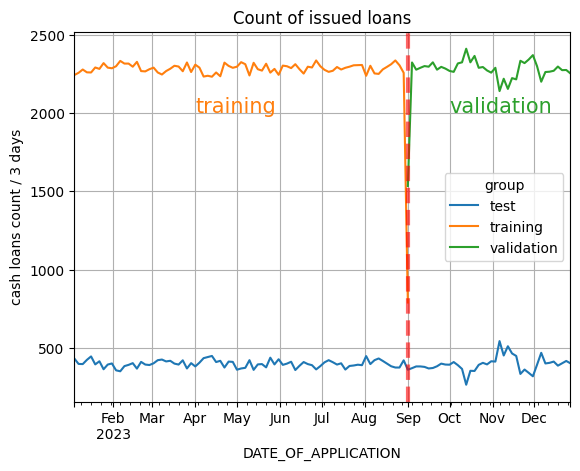

In [112]:
ids = all_features_df_upper['SK_ID_CURR']
all_features_df_upper['DAY_OF_YEAR'] = ((ids - ids.min()) / (ids.max() - ids.min()) * 365 + 1).astype(int)
all_features_df_upper['DATE_OF_APPLICATION'] = pd.to_datetime(2023 * 1000 + all_features_df_upper['DAY_OF_YEAR'], format='%Y%j')

# Определяем группы train/val/test
all_features_df_upper['IS_TRAINING'] = False
all_features_df_upper.loc[
    all_features_df_upper['DATE_OF_APPLICATION'].le('2023-09-01')
    & all_features_df_upper['TARGET'].notna(),
    'IS_TRAINING'
] = True

all_features_df_upper['group'] = 'training'
all_features_df_upper.loc[all_features_df_upper['TARGET'].isna(), 'group'] = 'test'
all_features_df_upper.loc[all_features_df_upper['TARGET'].notna() & all_features_df_upper['IS_TRAINING'].eq(False), 'group'] = 'validation'

# Визуализация
ax = all_features_df_upper[
    all_features_df_upper['NAME_CONTRACT_TYPE'].eq('Cash loans')
].groupby([
    'group',
    pd.Grouper(key='DATE_OF_APPLICATION', freq='3d'),
]).size().unstack(0).iloc[1:-1].plot(
    grid=True,
    title='Count of issued loans',
    ylabel='cash loans count / 3 days',
    lw=1.5,
)

ax.axvline('2023-09-01', color='r', lw=3, alpha=0.6, ls='--')
ax.text(x='2023-04-01', y=2005, s='training', color='tab:orange', fontsize=15)
ax.text(x='2023-10-01', y=2005, s='validation', color='tab:green', fontsize=15)

Заполнение пропусков, идентичное для уже обученной модели model_advanced

Для новых признаков заполняем нулем, поскольку 0 подходит для всех пропусков в NEW_FEATURES

In [113]:
all_features_df_upper[NUMERICAL_FEATURES] = all_features_df_upper[NUMERICAL_FEATURES].fillna(-1)
all_features_df_upper[EXT_SOURCE_FEATURES] = all_features_df_upper[EXT_SOURCE_FEATURES].fillna(-1)
all_features_df_upper[CAT_FEATURES] = all_features_df_upper[CAT_FEATURES].fillna('XNA')
all_features_df_upper[NEW_FEATURES] = all_features_df_upper[NEW_FEATURES].fillna(0)

Обучающая и валидационная выборки

In [114]:
training = all_features_df_upper[
    all_features_df_upper['NAME_CONTRACT_TYPE'].eq('Cash loans')
    & all_features_df_upper['group'].eq('training')
].reset_index(drop=True)

validation = all_features_df_upper[
    all_features_df_upper['NAME_CONTRACT_TYPE'].eq('Cash loans')
    & all_features_df_upper['group'].eq('validation')
].reset_index(drop=True)

Загружаем модель model_advanced

In [115]:
model_advanced = CatBoostClassifier().load_model(PROJECT_DIR / "src/metrics/model_advanced.pkl")

Загружаем или обучаем новую модель my_model, которая обучается на всех признаках ALL_FEATURES, включая новые сгенерированные

In [116]:
if GET_PREPARED_MODEL:
    my_model = CatBoostClassifier().load_model(PROJECT_DIR / "src/metrics/my_model.pkl")
else:
    my_model = CatBoostClassifier(
        depth=6,
        learning_rate=0.03,
        iterations=500,
        cat_features=CAT_FEATURES,
        verbose=100,
        random_seed=42
    )

    my_model.fit(
        X=training[ALL_FEATURES],
        y=training[TARGET],
        eval_set=(validation[ALL_FEATURES], validation[TARGET]),
        early_stopping_rounds=50,
        verbose=100
    )

    my_model.save_model(PROJECT_DIR / "src/metrics/my_model.pkl")

Смотрим важность признаков у модели model_advanced. Самые важные признаки выведены в датафрейме

In [117]:
model_advanced_feature_names = model_advanced.feature_names_
features = pd.DataFrame({
    'feature': model_advanced_feature_names,
    'importance': model_advanced.get_feature_importance()
})

features.sort_values('importance', ascending=False).head(10)

,feature,importance
75,EXT_SOURCE_1,23.959891
3,DAYS_BIRTH,17.012668
4,DAYS_EMPLOYED,9.534331
71,DAYS_LAST_PHONE_CHANGE,7.120262
6,DAYS_ID_PUBLISH,5.470051
73,CODE_GENDER,5.464566
16,REGION_RATING_CLIENT_W_CITY,3.881131
7,OWN_CAR_AGE,2.923454
15,REGION_RATING_CLIENT,2.888468
9,FLAG_EMP_PHONE,2.753980


Оцениваем пробу валидационной выборки, сортируем на 10 равных по количеству категорий (10 децилей)

Нас интересует вероятность дефолта (класс 1) - берем [:, 1]

In [118]:
validation['PROBA_model_advanced'] = model_advanced.predict_proba(
    X=validation[model_advanced_feature_names],
)[:, 1]

validation['QUANTILE_model_advanced'] = pd.qcut(
    validation['PROBA_model_advanced'],
    q=10,
)

validation['QUANTILE_NUMBER_model_advanced'] = pd.qcut(
    validation['PROBA_model_advanced'],
    q=10,
    labels=np.arange(10),
)

Вывод децилей по валидационной пробе

В 1-м дециле - самые "хорошие" клиенты (низкая вероятность дефолта), в 10-м дециле - самые "плохие" (высокая вероятность)

In [119]:
validation['QUANTILE_model_advanced'].value_counts().sort_index()

QUANTILE_model_advanced
(0.00442, 0.0333]    9223
(0.0333, 0.0443]     9222
(0.0443, 0.0536]     9222
(0.0536, 0.0631]     9223
(0.0631, 0.0733]     9222
(0.0733, 0.0851]     9222
(0.0851, 0.0994]     9223
(0.0994, 0.119]      9222
(0.119, 0.148]       9222
(0.148, 0.405]       9223
Name: count, dtype: int64

Строим сортировочную таблицу для модели model_advanced, наглядно видно возрастающий таргет в зависимости от дециля

In [120]:
sort_table_advanced = validation.groupby([
    'QUANTILE_NUMBER_model_advanced',
], observed=True).agg(
    count=pd.NamedAgg(column='SK_ID_CURR', aggfunc='count'),
    target=pd.NamedAgg(column='TARGET', aggfunc='mean'),
)
(
    sort_table_advanced
    .style
    .background_gradient(
        axis=0, 
        vmin=0, 
        vmax=0.22, 
        gmap=sort_table_advanced['target'], 
        cmap="coolwarm",
    )
)

,count,target
QUANTILE_NUMBER_model_advanced,,
0,9223,0.026672
1,9222,0.042290
2,9222,0.045435
3,9223,0.056381
4,9222,0.058339
5,9222,0.072435
6,9223,0.088474
7,9222,0.103015
8,9222,0.138148


Группируем по номеру дециля и считаем:

- count: количество клиентов в дециле
- target: средняя доля дефолтов (чем выше, тем хуже клиенты)
- mean_amount: средняя сумма кредита
- years_old_median: медианный возраст клиента
- AMT_GOODS_PRICE_median: медианная цена товара (для кредитов на товары)

In [121]:
sort_table_advanced = validation.groupby([
    'QUANTILE_NUMBER_model_advanced',
], observed=True).agg(
    count=pd.NamedAgg(column='SK_ID_CURR', aggfunc='count'),
    target=pd.NamedAgg(column='TARGET', aggfunc='mean'),
    mean_amount=pd.NamedAgg(column='AMT_CREDIT', aggfunc='mean'),
    years_old_median=pd.NamedAgg(column='DAYS_BIRTH', aggfunc=lambda item: np.median(item / 365)),
    AMT_GOODS_PRICE_median=pd.NamedAgg(column='AMT_GOODS_PRICE', aggfunc='median'),
)

(
    sort_table_advanced
    .style
    .format(
        '${:,.0f}',
        subset=['mean_amount', 'AMT_GOODS_PRICE_median'],
    )
    .format(
        '{:.0f} years',
        subset=['years_old_median'],
    )
    .background_gradient(
        axis=0, 
        vmin=0, 
        vmax=0.22, 
        gmap=sort_table_advanced['target'], 
        cmap="coolwarm",
    )
)

,count,target,mean_amount,years_old_median,AMT_GOODS_PRICE_median
QUANTILE_NUMBER_model_advanced,,,,,
0,9223,0.026672,"$749,846",-55 years,"$616,500"
1,9222,0.042290,"$691,726",-52 years,"$531,000"
2,9222,0.045435,"$662,106",-51 years,"$477,000"
3,9223,0.056381,"$647,226",-49 years,"$472,500"
4,9222,0.058339,"$641,567",-46 years,"$472,500"
5,9222,0.072435,"$628,921",-44 years,"$454,500"
6,9223,0.088474,"$602,928",-41 years,"$450,000"
7,9222,0.103015,"$585,317",-38 years,"$450,000"
8,9222,0.138148,"$557,140",-35 years,"$450,000"


Разделение клиентов по категориям и ограничениям представлено на рис. sort_table_model_advanced.png

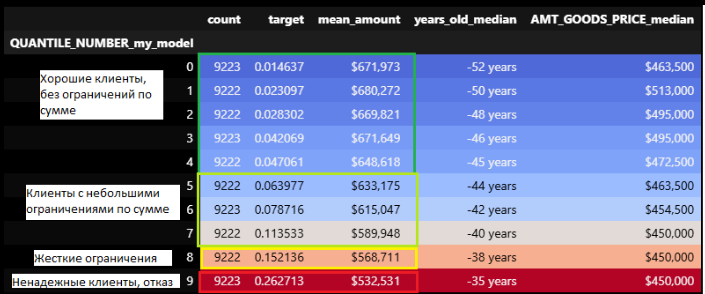

Аналогично для модели my_model - смотрим важность признаков. Видно, что сгенерированные признаки (взвешенный скор внешних источников, процентная ставка и др.) попали в список наиболее важных признаков

In [122]:
my_model_feature_names = my_model.feature_names_
features = pd.DataFrame({
    'feature': my_model_feature_names,
    'importance': my_model.get_feature_importance()
})

features.sort_values('importance', ascending=False).head(10)

,feature,importance
86,WEIGHTED_EXT_SCORE,37.222032
88,INTEREST_RATE,6.603594
72,EXT_SOURCE_1,5.956155
4,DAYS_EMPLOYED,3.552157
3,DAYS_BIRTH,3.428645
96,CREDIT_TYPE_CREDIT CARD,3.402687
74,CODE_GENDER,3.297315
80,AGE_AT_ID_CHANGE,2.606080
95,CREDIT_TYPE_CONSUMER CREDIT,2.541566
82,ANNUITY_TO_INCOME_PROPORTION,2.275612


Делим на децили по пробе на валидационной выборке

In [123]:
validation['PROBA_my_model'] = my_model.predict_proba(
    X=validation[my_model_feature_names],
)[:, 1]

validation['QUANTILE_my_model'] = pd.qcut(
    validation['PROBA_my_model'],
    q=10,
)

validation['QUANTILE_NUMBER_my_model'] = pd.qcut(
    validation['PROBA_my_model'],
    q=10,
    labels=np.arange(10),
)

In [124]:
validation['QUANTILE_my_model'].value_counts().sort_index()

QUANTILE_my_model
(0.00401, 0.0238]    9223
(0.0238, 0.0318]     9222
(0.0318, 0.0402]     9222
(0.0402, 0.0497]     9223
(0.0497, 0.0611]     9222
(0.0611, 0.0755]     9222
(0.0755, 0.0947]     9223
(0.0947, 0.122]      9222
(0.122, 0.173]       9222
(0.173, 0.845]       9223
Name: count, dtype: int64

Уже сейчас видно улучшение модели по сравнению с model_advanced: my_model гораздо лучше разделяет клиентов. В первых децилях таргет ниже, в последних - выше.

In [125]:
sort_table_my_model = validation.groupby([
    'QUANTILE_NUMBER_my_model',
], observed=True).agg(
    count=pd.NamedAgg(column='SK_ID_CURR', aggfunc='count'),
    target=pd.NamedAgg(column='TARGET', aggfunc='mean'),
)
(
    sort_table_my_model
    .style
    .background_gradient(
        axis=0, 
        vmin=0, 
        vmax=0.22, 
        gmap=sort_table_my_model['target'], 
        cmap="coolwarm",
    )
)

,count,target
QUANTILE_NUMBER_my_model,,
0,9223,0.014637
1,9222,0.023097
2,9222,0.028302
3,9223,0.042069
4,9222,0.047061
5,9222,0.063977
6,9223,0.078716
7,9222,0.113533
8,9222,0.152136


Построение сортировочной таблицы для my_model

In [126]:
sort_table_my_model = validation.groupby([
    'QUANTILE_NUMBER_my_model',
], observed=True).agg(
    count=pd.NamedAgg(column='SK_ID_CURR', aggfunc='count'),
    target=pd.NamedAgg(column='TARGET', aggfunc='mean'),
    mean_amount=pd.NamedAgg(column='AMT_CREDIT', aggfunc='mean'),
    years_old_median=pd.NamedAgg(column='DAYS_BIRTH', aggfunc=lambda item: np.median(item / 365)),
    AMT_GOODS_PRICE_median=pd.NamedAgg(column='AMT_GOODS_PRICE', aggfunc='median'),
)

(
    sort_table_my_model
    .style
    .format(
        '${:,.0f}',
        subset=['mean_amount', 'AMT_GOODS_PRICE_median'],
    )
    .format(
        '{:.0f} years',
        subset=['years_old_median'],
    )
    .background_gradient(
        axis=0, 
        vmin=0, 
        vmax=0.22, 
        gmap=sort_table_my_model['target'], 
        cmap="coolwarm",
    )
)

,count,target,mean_amount,years_old_median,AMT_GOODS_PRICE_median
QUANTILE_NUMBER_my_model,,,,,
0,9223,0.014637,"$671,973",-52 years,"$463,500"
1,9222,0.023097,"$680,272",-50 years,"$513,000"
2,9222,0.028302,"$669,821",-48 years,"$495,000"
3,9223,0.042069,"$671,649",-46 years,"$495,000"
4,9222,0.047061,"$648,618",-45 years,"$472,500"
5,9222,0.063977,"$633,175",-44 years,"$463,500"
6,9223,0.078716,"$615,047",-42 years,"$454,500"
7,9222,0.113533,"$589,948",-40 years,"$450,000"
8,9222,0.152136,"$568,711",-38 years,"$450,000"


Разделение клиентов по категориям и ограничениям представлено на рис. sort_table_my_model.png

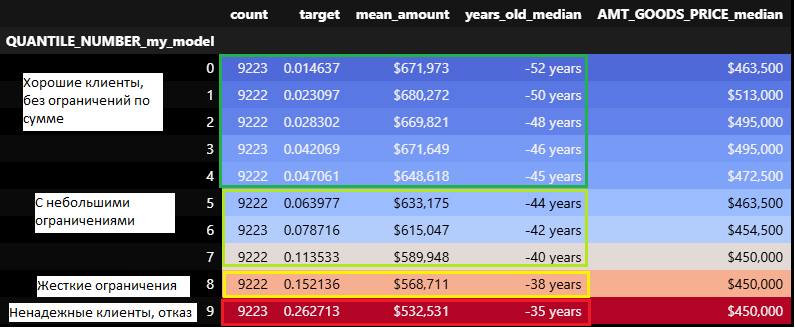

Вывод по сортировочным таблицам для двух моделей

Новая модель лучше разделила клиентов по риску. Самые хорошие клиенты стали еще лучше (меньше дефолтов), самые плохие - еще хуже (больше дефолтов). Это признак улучшения качества модели. Новая модель лучше сортирует клиентов. Это видно по более крутому росту target от дециля к децилю.

In [127]:
validation

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_AT_ID_CHANGE,AGE_FULL_YEARS,ANNUITY_TO_INCOME_PROPORTION,CHILDREN_PER_ADULT,CLOSED_CREDITS_COUNT,CLOSED_TO_TOTAL_CREDITS_PROPORTION,CLOSED_TYPE_ANOTHER TYPE OF LOAN,CLOSED_TYPE_CAR LOAN,CLOSED_TYPE_CASH LOAN (NON-EARMARKED),CLOSED_TYPE_CONSUMER CREDIT,CLOSED_TYPE_CREDIT CARD,CLOSED_TYPE_INTERBANK CREDIT,CLOSED_TYPE_LOAN FOR BUSINESS DEVELOPMENT,CLOSED_TYPE_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING),CLOSED_TYPE_LOAN FOR THE PURCHASE OF EQUIPMENT,CLOSED_TYPE_LOAN FOR WORKING CAPITAL REPLENISHMENT,CLOSED_TYPE_MICROLOAN,CLOSED_TYPE_MORTGAGE,CLOSED_TYPE_REAL ESTATE LOAN,CLOSED_TYPE_UNKNOWN TYPE OF LOAN,CREDIT_TYPE_ANOTHER TYPE OF LOAN,CREDIT_TYPE_CAR LOAN,CREDIT_TYPE_CASH LOAN (NON-EARMARKED),CREDIT_TYPE_CONSUMER CREDIT,CREDIT_TYPE_CREDIT CARD,CREDIT_TYPE_INTERBANK CREDIT,CREDIT_TYPE_LOAN FOR BUSINESS DEVELOPMENT,CREDIT_TYPE_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING),CREDIT_TYPE_LOAN FOR THE PURCHASE OF EQUIPMENT,CREDIT_TYPE_LOAN FOR WORKING CAPITAL REPLENISHMENT,CREDIT_TYPE_MICROLOAN,CREDIT_TYPE_MOBILE OPERATOR LOAN,CREDIT_TYPE_MORTGAGE,CREDIT_TYPE_REAL ESTATE LOAN,CREDIT_TYPE_UNKNOWN TYPE OF LOAN,DOCUMENT_COUNT,FULL_HOUSE_INFO,ID_CHANGE_DELAY,INCOME_DIFF_FROM_GROUP_AVG,INCOME_PER_ADULT,INCOME_PER_CHILD,INTEREST_RATE,LAST_ACTIVE_INTERVAL,LAST_CLOSED_INTERVAL,MAX_OVERDUE,MIN_OVERDUE,OPEN_CREDITS_COUNT,OPEN_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_1,OVERDUE_COUNT_1_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_2,OVERDUE_COUNT_2_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_3,OVERDUE_COUNT_3_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_4,OVERDUE_COUNT_4_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_5,OVERDUE_COUNT_5_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_PROPORTION,OVERDUE_TYPE_ANOTHER TYPE OF LOAN,OVERDUE_TYPE_CAR LOAN,OVERDUE_TYPE_CONSUMER CREDIT,OVERDUE_TYPE_CREDIT CARD,OVERDUE_TY

График сортировочной кривой на валидации.

Было решено сделать именно такое разделение клиентов по категориям, т.к. 4 и 5 децили имеют не слишком большую разницу, то 5 квантиль можно отнести к группе хороших клиентов без ограничений. Таким образом, увеличим количество клиентов, у которых не будет ограничений

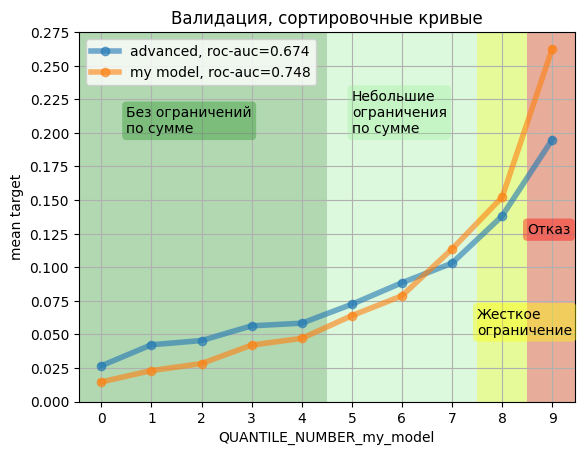

In [128]:
score = roc_auc_score(validation[TARGET], validation['PROBA_model_advanced'])
ax = sort_table_advanced['target'].plot(
    xticks=np.arange(10),
    marker='o',
    lw=4,
    alpha=0.6,
    grid=True,
    title='Валидация, сортировочные кривые',
    ylabel='mean target',
    label=f'advanced, roc-auc={score:.3f}',
)

score = roc_auc_score(validation[TARGET], validation['PROBA_my_model'])
ax = sort_table_my_model['target'].plot(
    xticks=np.arange(10),
    marker='o',
    lw=4,
    alpha=0.6,
    grid=True,
    ylabel='mean target',
    label=f'my model, roc-auc={score:.3f}',
)

ax.set_yticks(np.arange(0, 0.30, 0.025))
ax.legend()
ax.add_patch(patches.Rectangle((-0.5, 0), 5, 0.275, linewidth=0, facecolor='green', alpha=0.3))
ax.add_patch(patches.Rectangle((4.5, 0), 5, 0.275, linewidth=0, facecolor='lightgreen', alpha=0.3))
ax.add_patch(patches.Rectangle((7.5, 0), 1, 0.275, linewidth=0, facecolor='yellow', alpha=0.3))
ax.add_patch(patches.Rectangle((8.5, 0), 1, 0.275, linewidth=0, facecolor='red', alpha=0.3))

ax.text(0.5, 0.2, 'Без ограничений\nпо сумме', color='k', bbox=dict(facecolor='green', lw=0, alpha=0.3, boxstyle='round, pad=0.3'))
ax.text(5, 0.2, 'Небольшие\nограничения\nпо сумме', color='k', bbox=dict(facecolor='lightgreen', lw=0, alpha=0.3, boxstyle='round, pad=0.3'))
ax.text(7.5, 0.05, 'Жесткое\nограничение', color='k', bbox=dict(facecolor='yellow', lw=0, alpha=0.4, boxstyle='round, pad=0.3'))
ax.text(8.5, 0.125, 'Отказ', color='k', bbox=dict(facecolor='red', lw=0, alpha=0.4, boxstyle='round, pad=0.3'))

plt.savefig(PROJECT_DIR / 'src/metrics/sorting_curves.png')

Выводы по сортировочным кривым

Кривая модели my_model лучше разделяет клиентов. У плохих клиентов таргет стал выше, а у хороших - меньше. 5 (по порядку) дециль был отнесен к первой группе клиентов. Разрыв между лучшими и худшими клиентами увеличился у новой модели. Это показывает улучшение ранжирующей способности модели

In [129]:
validation['CLIENT_CATEGORY_model_advanced'] = pd.cut(
    validation['QUANTILE_NUMBER_model_advanced'],
    bins=[-np.inf, 4.5, 7.5, 8.5, np.inf],
)

validation['CLIENT_CATEGORY_my_model'] = pd.cut(
    validation['QUANTILE_NUMBER_my_model'],
    bins=[-np.inf, 4.5, 7.5, 8.5, np.inf],
)

Модель my_model

In [130]:
client_categories_my_model = validation.groupby([
    'CLIENT_CATEGORY_my_model',
]).agg(
    count=pd.NamedAgg(column='SK_ID_CURR', aggfunc='count'),
    target=pd.NamedAgg(column='TARGET', aggfunc='mean'),
)
(
    client_categories_my_model
    .style
    .background_gradient(axis=0, vmin=0, vmax=0.22, gmap=client_categories_my_model['target'], cmap="coolwarm")
)

C:\Users\Сергей\AppData\Local\Temp\ipykernel_16480\2771529408.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  client_categories_my_model = validation.groupby([


,count,target
CLIENT_CATEGORY_my_model,,
"(-inf, 4.5]",46112,0.031033
"(4.5, 7.5]",27667,0.085409
"(7.5, 8.5]",9222,0.152136
"(8.5, inf]",9223,0.262713


Advanced модель

In [131]:
client_categories_model_advanced = validation.groupby([
    'CLIENT_CATEGORY_model_advanced',
]).agg(
    count=pd.NamedAgg(column='SK_ID_CURR', aggfunc='count'),
    target=pd.NamedAgg(column='TARGET', aggfunc='mean'),
)
(
    client_categories_model_advanced[['count', 'target']]
    .style
    .background_gradient(axis=0, vmin=0, vmax=0.22, gmap=client_categories_model_advanced['target'], cmap="coolwarm")
)

C:\Users\Сергей\AppData\Local\Temp\ipykernel_16480\2357525738.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  client_categories_model_advanced = validation.groupby([


,count,target
CLIENT_CATEGORY_model_advanced,,
"(-inf, 4.5]",46112,0.045823
"(4.5, 7.5]",27667,0.087975
"(7.5, 8.5]",9222,0.138148
"(8.5, inf]",9223,0.195056


Матрица переходов клиентов. Эта же матрица с разделением по децилям и группам клиентов приведена в transitions_matrix_models.png

In [132]:
transitions = validation.groupby([
    'QUANTILE_NUMBER_model_advanced',
    'QUANTILE_NUMBER_my_model',
])['SK_ID_CURR'].count().unstack()

(
    transitions
    .style
    .background_gradient(axis=None, cmap='Blues')
)

C:\Users\Сергей\AppData\Local\Temp\ipykernel_16480\4210296793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transitions = validation.groupby([


QUANTILE_NUMBER_my_model,0,1,2,3,4,5,6,7,8,9
QUANTILE_NUMBER_model_advanced,,,,,,,,,,
0,4293,1974,1219,808,445,248,129,71,26,10
1,2111,1994,1522,1220,942,656,400,233,112,32
2,1258,1687,1479,1342,1188,935,688,394,185,66
3,744,1308,1455,1310,1252,1158,867,619,337,173
4,413,1013,1212,1297,1290,1231,1155,842,520,249
5,215,639,973,1121,1230,1260,1322,1222,852,388
6,113,330,708,959,1095,1249,1392,1425,1279,673
7,59,194,403,687,916,1149,1358,1596,1710,1150
8,15,68,210,376,623,887,1173,1651,2112,2107


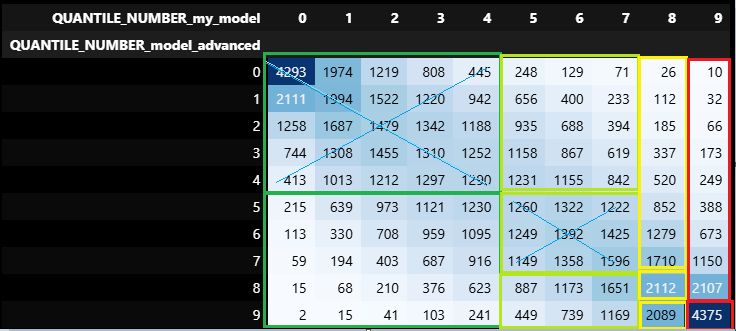

- хорошие клиенты стали еще лучше
- плохие клиенты стали заметно хуже
- переход "хороших" клиентов в более низкие децили: некоторые клиенты из дециля 0 модели model_adnvaced (около 100 клиентов) перешли в децили 7-9 модели my_model. Аналогично, клиенты из дециля 9 модели model_adnvaced (58 клиентов) перешли в децили 0-2 модели my_model. Это неизбежные ошибки, но их доля мала

Модель my_model является улучшенной версией, она сохраняет общую структуру оценок model_adnvaced, но делает её более контрастной

Наблюдается систематический сдвиг вправо-вниз (так как значения на главной диагонали не самые высокие), клиенты из каждого дециля model_adnvaced в среднем переходят в более высокие децили my_model (то есть оцениваются как более рисковые). my_model в целом строже оценивает клиентов, чем model_advanced

In [133]:
(
    transitions
    .div(transitions.sum(axis=1), axis=0)
    .mul(100)
    .style
    .format('{:.0f}%')
    .background_gradient(axis=None, cmap='Blues')
)

QUANTILE_NUMBER_my_model,0,1,2,3,4,5,6,7,8,9
QUANTILE_NUMBER_model_advanced,,,,,,,,,,
0,47%,21%,13%,9%,5%,3%,1%,1%,0%,0%
1,23%,22%,17%,13%,10%,7%,4%,3%,1%,0%
2,14%,18%,16%,15%,13%,10%,7%,4%,2%,1%
3,8%,14%,16%,14%,14%,13%,9%,7%,4%,2%
4,4%,11%,13%,14%,14%,13%,13%,9%,6%,3%
5,2%,7%,11%,12%,13%,14%,14%,13%,9%,4%
6,1%,4%,8%,10%,12%,14%,15%,15%,14%,7%
7,1%,2%,4%,7%,10%,12%,15%,17%,19%,12%
8,0%,1%,2%,4%,7%,10%,13%,18%,23%,23%


Сделаем по бизнес-категориям клиентов

In [134]:
transitions_categories = validation.groupby([
    'CLIENT_CATEGORY_model_advanced',
    'CLIENT_CATEGORY_my_model',
])['SK_ID_CURR'].count().unstack()

(
    transitions_categories
    .style
    .background_gradient(axis=None, cmap='Blues')
)

C:\Users\Сергей\AppData\Local\Temp\ipykernel_16480\4273892493.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transitions_categories = validation.groupby([


CLIENT_CATEGORY_my_model,"(-inf, 4.5]","(4.5, 7.5]","(7.5, 8.5]","(8.5, inf]"
CLIENT_CATEGORY_model_advanced,,,,
"(-inf, 4.5]",34776,9626,1180,530
"(4.5, 7.5]",9642,11973,3841,2211
"(7.5, 8.5]",1292,3711,2112,2107
"(8.5, inf]",402,2357,2089,4375


Эта таблица показывает переходы между укрупненными бизнес-категориями

In [135]:
(
    transitions_categories
    .div(transitions_categories.sum(axis=1), axis=0)
    .mul(100)
    .style
    .format('{:.1f}%')
    .background_gradient(axis=None, cmap='Blues')
)

CLIENT_CATEGORY_my_model,"(-inf, 4.5]","(4.5, 7.5]","(7.5, 8.5]","(8.5, inf]"
CLIENT_CATEGORY_model_advanced,,,,
"(-inf, 4.5]",75.4%,20.9%,2.6%,1.1%
"(4.5, 7.5]",34.9%,43.3%,13.9%,8.0%
"(7.5, 8.5]",14.0%,40.2%,22.9%,22.8%
"(8.5, inf]",4.4%,25.6%,22.6%,47.4%


Зеленая зона новой модели my_model на 69,7% состоит из клиентов, которые и раньше были в зеленой зоне. Еще 28% - это клиенты из светло-зеленой зоны (небольшие ограничения), которых новая модель переопределила в хорошие. 47% клиентов, которых старая модель считала рискованными и отправляла в зону жестких ограничений, новая модель перевела их в зону небольших ограничений. модель стала лучше видеть хороших клиентов среди тех, кого старая модель считала средними.

Анализ переходов между бизнес-категориями подтверждает, что модель my_model улучшает качество скоринга.

Подвержена ли модель my_model дата-дрифту - проверить распределение децилей на тесте во времени

In [136]:
test = all_features_df_upper[
    all_features_df_upper['NAME_CONTRACT_TYPE'].eq('Cash loans')
    & all_features_df_upper['group'].eq('test')
].reset_index(drop=True)

In [137]:
test['PROBA_my_model'] = my_model.predict_proba(
    X=test[ALL_FEATURES],
)[:, 1]

In [138]:
test['QUANTILE_NUMBER_my_model'] = 0
quantile_thresholds = validation['QUANTILE_my_model'].unique().sort_values(ascending=True)
for category, interval in enumerate(quantile_thresholds):
    test.loc[
        test['PROBA_my_model'].gt(interval.left),
        'QUANTILE_NUMBER_my_model'
    ] = category

In [139]:
quantile_thresholds

[(0.00401, 0.0238], (0.0238, 0.0318], (0.0318, 0.0402], (0.0402, 0.0497], (0.0497, 0.0611], (0.0611, 0.0755], (0.0755, 0.0947], (0.0947, 0.122], (0.122, 0.173], (0.173, 0.845]]
Categories (10, interval[float64, right]): [(0.00401, 0.0238] < (0.0238, 0.0318] < (0.0318, 0.0402] < (0.0402, 0.0497] ... (0.0755, 0.0947] < (0.0947, 0.122] < (0.122, 0.173] < (0.173, 0.845]]

In [140]:
test

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_AT_ID_CHANGE,AGE_FULL_YEARS,ANNUITY_TO_INCOME_PROPORTION,CHILDREN_PER_ADULT,CLOSED_CREDITS_COUNT,CLOSED_TO_TOTAL_CREDITS_PROPORTION,CLOSED_TYPE_ANOTHER TYPE OF LOAN,CLOSED_TYPE_CAR LOAN,CLOSED_TYPE_CASH LOAN (NON-EARMARKED),CLOSED_TYPE_CONSUMER CREDIT,CLOSED_TYPE_CREDIT CARD,CLOSED_TYPE_INTERBANK CREDIT,CLOSED_TYPE_LOAN FOR BUSINESS DEVELOPMENT,CLOSED_TYPE_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING),CLOSED_TYPE_LOAN FOR THE PURCHASE OF EQUIPMENT,CLOSED_TYPE_LOAN FOR WORKING CAPITAL REPLENISHMENT,CLOSED_TYPE_MICROLOAN,CLOSED_TYPE_MORTGAGE,CLOSED_TYPE_REAL ESTATE LOAN,CLOSED_TYPE_UNKNOWN TYPE OF LOAN,CREDIT_TYPE_ANOTHER TYPE OF LOAN,CREDIT_TYPE_CAR LOAN,CREDIT_TYPE_CASH LOAN (NON-EARMARKED),CREDIT_TYPE_CONSUMER CREDIT,CREDIT_TYPE_CREDIT CARD,CREDIT_TYPE_INTERBANK CREDIT,CREDIT_TYPE_LOAN FOR BUSINESS DEVELOPMENT,CREDIT_TYPE_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING),CREDIT_TYPE_LOAN FOR THE PURCHASE OF EQUIPMENT,CREDIT_TYPE_LOAN FOR WORKING CAPITAL REPLENISHMENT,CREDIT_TYPE_MICROLOAN,CREDIT_TYPE_MOBILE OPERATOR LOAN,CREDIT_TYPE_MORTGAGE,CREDIT_TYPE_REAL ESTATE LOAN,CREDIT_TYPE_UNKNOWN TYPE OF LOAN,DOCUMENT_COUNT,FULL_HOUSE_INFO,ID_CHANGE_DELAY,INCOME_DIFF_FROM_GROUP_AVG,INCOME_PER_ADULT,INCOME_PER_CHILD,INTEREST_RATE,LAST_ACTIVE_INTERVAL,LAST_CLOSED_INTERVAL,MAX_OVERDUE,MIN_OVERDUE,OPEN_CREDITS_COUNT,OPEN_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_1,OVERDUE_COUNT_1_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_2,OVERDUE_COUNT_2_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_3,OVERDUE_COUNT_3_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_4,OVERDUE_COUNT_4_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_COUNT_5,OVERDUE_COUNT_5_TO_TOTAL_CREDITS_PROPORTION,OVERDUE_PROPORTION,OVERDUE_TYPE_ANOTHER TYPE OF LOAN,OVERDUE_TYPE_CAR LOAN,OVERDUE_TYPE_CONSUMER CREDIT,OVERDUE_TYPE_CREDIT CARD,OVERDUE_TY

In [141]:
sort_table_test = test.groupby([
    'QUANTILE_NUMBER_my_model',
]).agg(
    count=pd.NamedAgg(column='SK_ID_CURR', aggfunc='count'),
    mean_amount=pd.NamedAgg(column='AMT_CREDIT', aggfunc='mean'),
)

sort_table_test['ratio'] = sort_table_test['count'].div(sort_table_test['count'].sum()).mul(100)
(
    sort_table_test
    .style
    .format('${:,.0f}', subset=['mean_amount'])
    .format('{:.1f}%', subset=['ratio'])
)

,count,mean_amount,ratio
QUANTILE_NUMBER_my_model,,,
0,5315,"$547,900",11.0%
1,4955,"$562,931",10.3%
2,4936,"$549,660",10.2%
3,4892,"$551,851",10.1%
4,4976,"$529,210",10.3%
5,4772,"$518,599",9.9%
6,4752,"$499,918",9.8%
7,4609,"$481,870",9.5%
8,4804,"$476,043",9.9%


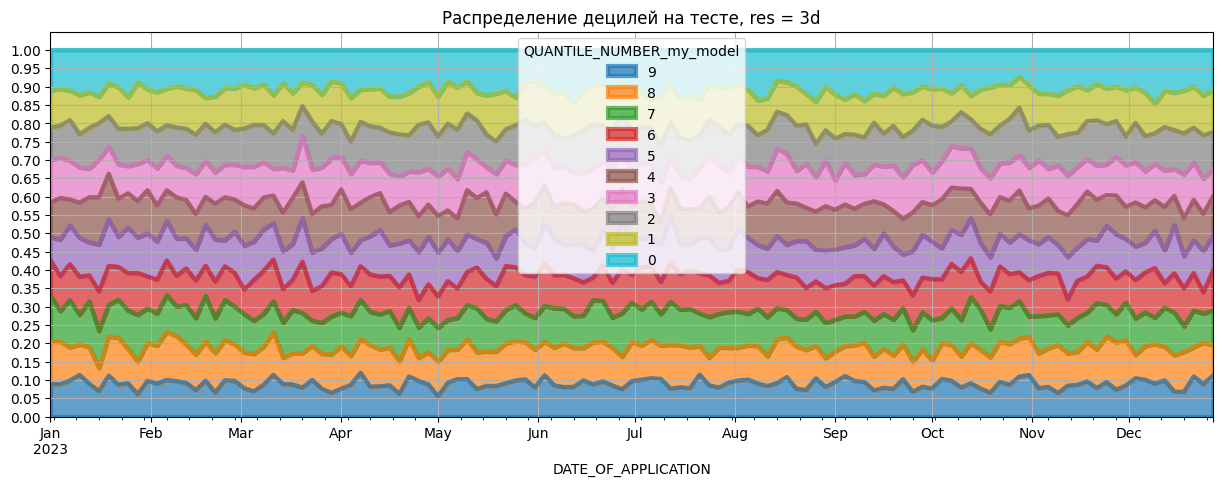

In [142]:
res = '3d'
info = test.groupby([
    pd.Grouper(key='DATE_OF_APPLICATION', freq=res),
    'QUANTILE_NUMBER_my_model',
])['SK_ID_CURR'].count().unstack().iloc[:-1]

info = info.reindex(sorted(info.columns, reverse=True), axis=1)

info = info.div(info.sum(axis=1), axis=0)

ax = info.plot.area(
    figsize=(15, 5),
    grid=True,
    alpha=0.7,
    lw=3,
    yticks=np.arange(0, 1.05, 0.05),
    title=f'Распределение децилей на тесте, res = {res}',
)

plt.savefig(PROJECT_DIR / 'src/metrics/data_drift_analyse.png')

### Вывод по распределению на тесте

Распределение децилей на тестовой выборке близко к равномерному, но наблюдаются небольшие отклонения:

- дециль 0 (лучшие клиенты) - доля 11.0%
- дециль 9 (худшие клиенты) - доля 8.9%
- остальные децили имеют отклонения от 10% в пределах 0.5%

Признаков значимого дата-дрифта не обнаружено. Распределение децилей на тестовой выборке близко к равномерному. Отклонения в крайних децилях составляют около 1%, что не превышает допустимый уровень, небольшой data-drift может быть не страшен.

для борьбы с дата-дрифтом необходимо:
- регулярно мониторить модель на предмет смещения распределения признаков
- отслеживать качество модели по метрикам (ROC-AUC, target в категориях)
- планировать периодическое переобучение модели (например, раз в квартал или при накоплении значительного объема новых данных)

Модель my_model не подвержена значимому дата-дрифту на тестовой выборке.

Просмотр отдельного примера

In [163]:
# Находим клиентов, которые были в дециле 0 у advanced, но стали в дециле 9 у my_model
bad = validation[
    (validation['QUANTILE_NUMBER_model_advanced'] == 0) &
    (validation['QUANTILE_NUMBER_my_model'] == 9)
].copy()

print(f"Клиентов из дециля 0 advanced в дециль 9 my_model: {len(bad)}")

# Находим клиентов, которые были в дециле 9 у advanced, но стали в дециле 0 у my_model
good = validation[
    (validation['QUANTILE_NUMBER_model_advanced'] == 9) &
    (validation['QUANTILE_NUMBER_my_model'] == 0)
].copy()

print(f"Клиентов из дециля 9 advanced в дециль 0 my_model: {len(good)}")

Клиентов из дециля 0 advanced в дециль 9 my_model: 10
Клиентов из дециля 9 advanced в дециль 0 my_model: 2


In [162]:
example_client = good.iloc[0]
client_id = example_client['SK_ID_CURR']

print(f"Номер: {client_id}")
print("Проба:")
print(f"model_advanced: {example_client['PROBA_model_advanced']:.4f}")
print(f"my_model: {example_client['PROBA_my_model']:.4f}")
print(f"Дефолт = {example_client['TARGET']}")

print()
print("Топ-10 признаков model_advanced у этого клиента:")

# Топ-10 важных признаков model_advanced
top_features = pd.DataFrame({
    'feature': model_advanced.feature_names_,
    'importance': model_advanced.get_feature_importance()
}).sort_values('importance', ascending=False).head(10)

for f in top_features['feature']:
    if f in example_client:
        print(f"{f}: {example_client[f]}")

print()
print("Топ-10 признаков my_model у этого клиента:")

# Топ-10 важных признаков my_model
top_features = pd.DataFrame({
    'feature': my_model.feature_names_,
    'importance': my_model.get_feature_importance()
}).sort_values('importance', ascending=False).head(10)

for f in top_features['feature']:
    if f in example_client:
        print(f"{f}: {example_client[f]}")


Номер: 354737
Проба:
model_advanced: 0.1789
my_model: 0.0180
Дефолт = 0.0

Топ-10 признаков model_advanced у этого клиента:
EXT_SOURCE_1: 0.18895015
DAYS_BIRTH: -10199
DAYS_EMPLOYED: -489
DAYS_LAST_PHONE_CHANGE: -277.0
DAYS_ID_PUBLISH: -2878
CODE_GENDER: M
REGION_RATING_CLIENT_W_CITY: 2.0
OWN_CAR_AGE: -1.0
REGION_RATING_CLIENT: 2.0
FLAG_EMP_PHONE: 1

Топ-10 признаков my_model у этого клиента:
WEIGHTED_EXT_SCORE: 0.5596873777139049
INTEREST_RATE: 9.075068037498024
EXT_SOURCE_1: 0.18895015
DAYS_EMPLOYED: -489
DAYS_BIRTH: -10199
CREDIT_TYPE_CREDIT CARD: 2.0
CODE_GENDER: M
AGE_AT_ID_CHANGE: 20
CREDIT_TYPE_CONSUMER CREDIT: 13.0
ANNUITY_TO_INCOME_PROPORTION: 0.0910285714285714


Модель model_advanced отказала клиенту, т.к. исходя из наиболе важных признаков:

- EXT_SOURCE_1 очень низкий,
- стаж работы около 1 года (DAYS_EMPLOYED: -489)
- возраст около 28 лет (DAYS_BIRTH: -10199)

Модель my_model оказалась права и одобрила клиента, т.к. исходя из наиболе важных признаков:

- WEIGHTED_EXT_SCORE хороший (0.56), перевесил низкий EXT_SOURCE_1
- отношение выплаты к доходу низкое (ANNUITY_TO_INCOME_PROPORTION: 0.09)
- ставка адекватная (INTEREST_RATE: 9.08)

In [159]:
example_client = bad.iloc[0]
client_id = example_client['SK_ID_CURR']

print(f"Номер: {client_id}")
print("Проба:")
print(f"model_advanced: {example_client['PROBA_model_advanced']:.4f}")
print(f"my_model: {example_client['PROBA_my_model']:.4f}")
print(f"Дефолт = {example_client['TARGET']}")

print()
print("Топ-10 признаков model_advanced у этого клиента:")

# Топ-10 важных признаков model_advanced
top_features = pd.DataFrame({
    'feature': model_advanced.feature_names_,
    'importance': model_advanced.get_feature_importance()
}).sort_values('importance', ascending=False).head(10)

for f in top_features['feature']:
    if f in example_client:
        print(f"{f}: {example_client[f]}")

print()
print("Топ-10 признаков my_model у этого клиента:")

# Топ-10 важных признаков my_model
top_features = pd.DataFrame({
    'feature': my_model.feature_names_,
    'importance': my_model.get_feature_importance()
}).sort_values('importance', ascending=False).head(10)

for f in top_features['feature']:
    if f in example_client:
        print(f"{f}: {example_client[f]}")


Номер: 339273
Проба:
model_advanced: 0.0332
my_model: 0.1837
Дефолт = 0.0

Топ-10 признаков model_advanced у этого клиента:
EXT_SOURCE_1: 0.6127839
DAYS_BIRTH: -20762
DAYS_EMPLOYED: 365243
DAYS_LAST_PHONE_CHANGE: -132.0
DAYS_ID_PUBLISH: -4262
CODE_GENDER: F
REGION_RATING_CLIENT_W_CITY: 3.0
OWN_CAR_AGE: 5.0
REGION_RATING_CLIENT: 3.0
FLAG_EMP_PHONE: 0

Топ-10 признаков my_model у этого клиента:
WEIGHTED_EXT_SCORE: 0.2749266024088105
INTEREST_RATE: 4.158853567053544
EXT_SOURCE_1: 0.6127839
DAYS_EMPLOYED: 365243
DAYS_BIRTH: -20762
CREDIT_TYPE_CREDIT CARD: 4.0
CODE_GENDER: F
AGE_AT_ID_CHANGE: 45
CREDIT_TYPE_CONSUMER CREDIT: 2.0
ANNUITY_TO_INCOME_PROPORTION: 0.3888571428571428


Модель my_model ошиблась и отказала клиенту, т.к. исходя из наиболее важных признаков:
- WEIGHTED_EXT_SCORE низкий (0.27)
- аномальный стаж (DAYS_EMPLOYED: 365243)
- отношение выплаты к доходу высокое (ANNUITY_TO_INCOME_PROPORTION: 0.39)
- много кредитных карт (CREDIT_TYPE_CREDIT CARD: 4.0)

Модель model_advanced оказалась права и одобрила клиента, т.к.:
- EXT_SOURCE_1 нормальный (0.61)
- возраст около 57 лет (DAYS_BIRTH: -20762)